In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import os
import joblib
import json

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

final_data = pd.read_csv("Data/Data_Final.csv")
final_data["timestamp_hour"] = pd.to_datetime(final_data["timestamp_hour"])

final_data = final_data.sort_values(
    ["regency", "timestamp_hour"]
).reset_index(drop=True)

print("Ukuran dataset air quality:", final_data.shape)

Ukuran dataset air quality: (70088, 35)


In [3]:
# =========================
# FEATURE ENGINEERING WAKTU
# =========================

final_data["hour"] = final_data["timestamp_hour"].dt.hour
final_data["dayofweek"] = final_data["timestamp_hour"].dt.dayofweek
final_data["day"] = final_data["timestamp_hour"].dt.day
final_data["month"] = final_data["timestamp_hour"].dt.month
final_data["is_weekend"] = final_data["dayofweek"].isin([5, 6]).astype(int)

display(
    final_data[
        ["timestamp_hour", "regency", "hour", "dayofweek", "day", "month", "is_weekend"]
    ].head()
)

,timestamp_hour,regency,hour,dayofweek,day,month,is_weekend
0,2025-06-14 00:00:00,Kabupaten Badung,0,5,14,6,1
1,2025-06-14 01:00:00,Kabupaten Badung,1,5,14,6,1
2,2025-06-14 02:00:00,Kabupaten Badung,2,5,14,6,1
3,2025-06-14 03:00:00,Kabupaten Badung,3,5,14,6,1
4,2025-06-14 04:00:00,Kabupaten Badung,4,5,14,6,1


In [4]:
# =========================
# FEATURE ENGINEERING MUSIM
# Bali / Indonesia:
# April - Oktober  = musim kemarau = 0
# November - Maret = musim hujan   = 1
# =========================

def get_season_binary(month):
    if month in [4, 5, 6, 7, 8, 9, 10]:
        return 0   # kemarau
    else:
        return 1   # hujan

final_data["season"] = final_data["month"].apply(get_season_binary)

display(
    final_data[
        ["timestamp_hour", "regency", "month", "season"]
    ].head()
)

,timestamp_hour,regency,month,season
0,2025-06-14 00:00:00,Kabupaten Badung,6,0
1,2025-06-14 01:00:00,Kabupaten Badung,6,0
2,2025-06-14 02:00:00,Kabupaten Badung,6,0
3,2025-06-14 03:00:00,Kabupaten Badung,6,0
4,2025-06-14 04:00:00,Kabupaten Badung,6,0


In [5]:
# =========================
# POLLUTANT LAG FEATURES
# lag_1, lag_3, lag_6, lag_12, lag_24
# =========================

pollutant_cols = [
    "co",
    "no",
    "no2",
    "o3",
    "so2",
    "pm2_5",
    "pm10",
    "nh3"
]

lag_hours = [1, 3, 6, 12, 24]

for col in pollutant_cols:
    for lag in lag_hours:
        final_data[f"{col}_lag_{lag}"] = (
            final_data
            .groupby("regency")[col]
            .shift(lag)
        )

lag_features = [
    f"{col}_lag_{lag}"
    for col in pollutant_cols
    for lag in lag_hours
]

display(
    final_data[
        ["timestamp_hour", "regency"] + lag_features[:10]
    ].head(30)
)

,timestamp_hour,regency,co_lag_1,co_lag_3,co_lag_6,co_lag_12,co_lag_24,no_lag_1,no_lag_3,no_lag_6,no_lag_12,no_lag_24
0,2025-06-14 00:00:00,Kabupaten Badung,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-06-14 01:00:00,Kabupaten Badung,84.352308,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
2,2025-06-14 02:00:00,Kabupaten Badung,84.763590,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
3,2025-06-14 03:00:00,Kabupaten Badung,85.450385,84.352308,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
4,2025-06-14 04:00:00,Kabupaten Badung,85.944615,84.763590,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
5,2025-06-14 05:00:00,Kabupaten Badung,86.232949,85.450385,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
6,2025-06-14 06:00:00,Kabupaten Badung,86.314615,85.944615,84.352308,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
7,2025-06-14 07:00:00,Kabupaten Badung,86.601410,86.232949,84.763590,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
8,2025-06-14 08:00:00,Kabupaten Badung,86.831923,86.314615,85.450385,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
9,2025-06-14 09:00:00,Kabupaten Badung,87.089231,86.601410,85.944615,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN


In [6]:
# =========================
# POLLUTANT ROLLING AVERAGE FEATURES
# Rolling average 3, 6, dan 24 jam
# shift(1) digunakan agar tidak memakai nilai pada jam yang sama
# =========================

rolling_windows = [3, 6, 24]

for col in pollutant_cols:
    for window in rolling_windows:
        final_data[f"{col}_rolling_avg_{window}"] = (
            final_data
            .groupby("regency")[col]
            .transform(lambda x: x.shift(1).rolling(window=window).mean())
        )

rolling_features = [
    f"{col}_rolling_avg_{window}"
    for col in pollutant_cols
    for window in rolling_windows
]

display(
    final_data[
        ["timestamp_hour", "regency"] + rolling_features[:10]
    ].head(30)
)

,timestamp_hour,regency,co_rolling_avg_3,co_rolling_avg_6,co_rolling_avg_24,no_rolling_avg_3,no_rolling_avg_6,no_rolling_avg_24,no2_rolling_avg_3,no2_rolling_avg_6,no2_rolling_avg_24,o3_rolling_avg_3
0,2025-06-14 00:00:00,Kabupaten Badung,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-06-14 01:00:00,Kabupaten Badung,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-06-14 02:00:00,Kabupaten Badung,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-06-14 03:00:00,Kabupaten Badung,84.855427,NaN,NaN,0.000000,NaN,NaN,0.083162,NaN,NaN,41.710598
4,2025-06-14 04:00:00,Kabupaten Badung,85.386197,NaN,NaN,0.000000,NaN,NaN,0.085385,NaN,NaN,41.943590
5,2025-06-14 05:00:00,Kabupaten Badung,85.875983,NaN,NaN,0.000000,NaN,NaN,0.086966,NaN,NaN,42.115470
6,2025-06-14 06:00:00,Kabupaten Badung,86.164060,85.509744,NaN,0.000000,0.000000,NaN,0.090769,0.086966,NaN,42.261282
7,2025-06-14 07:00:00,Kabupaten Badung,86.382991,85.884594,NaN,0.000000,0.000000,NaN,0.094060,0.089722,NaN,42.360214
8,2025-06-14 08:00:00,Kabupaten Badung,86.582650,86.229316,NaN,0.000000,0.000000,NaN,0.099017,0.092991,NaN,42.486795
9,2025-06-14 09:00:00,Kabupaten Badung,86.840855,86.502457,NaN,0.000000,0.000000,NaN,0.101752,0.096261,NaN,42.652821


In [7]:
# =========================
# MEMBUAT TARGET 24 JAM KE DEPAN
# =========================

forecast_horizon = 24

for col in pollutant_cols:
    final_data[f"{col}_target_24h"] = (
        final_data
        .groupby("regency")[col]
        .shift(-forecast_horizon)
    )

target_cols = [
    f"{col}_target_24h"
    for col in pollutant_cols
]

print("Kolom target:")
print(target_cols)

display(
    final_data[
        ["timestamp_hour", "regency"] + pollutant_cols + target_cols
    ].head()
)

Kolom target:
['co_target_24h', 'no_target_24h', 'no2_target_24h', 'o3_target_24h', 'so2_target_24h', 'pm2_5_target_24h', 'pm10_target_24h', 'nh3_target_24h']


,timestamp_hour,regency,co,no,no2,o3,so2,pm2_5,pm10,nh3,co_target_24h,no_target_24h,no2_target_24h,o3_target_24h,so2_target_24h,pm2_5_target_24h,pm10_target_24h,nh3_target_24h
0,2025-06-14 00:00:00,Kabupaten Badung,84.352308,0.0,0.079744,41.466795,0.083462,5.769103,8.508718,0.0,103.298333,0.0,0.124615,43.816154,0.098205,6.559103,9.400256,0.094231
1,2025-06-14 01:00:00,Kabupaten Badung,84.763590,0.0,0.084872,41.732179,0.088590,5.915513,8.751282,0.0,102.797821,0.0,0.131282,43.826795,0.086795,6.083718,8.521282,0.110897
2,2025-06-14 02:00:00,Kabupaten Badung,85.450385,0.0,0.084872,41.932821,0.088590,5.855128,8.631795,0.0,102.289872,0.0,0.131282,43.787308,0.070128,5.734359,7.722308,0.104231
3,2025-06-14 03:00:00,Kabupaten Badung,85.944615,0.0,0.086410,42.165769,0.083333,5.713205,8.316410,0.0,101.613974,0.0,0.131282,43.564872,0.070128,5.622051,7.511667,0.086026
4,2025-06-14 04:00:00,Kabupaten Badung,86.232949,0.0,0.089615,42.247821,0.083333,5.592436,8.110641,0.0,101.300256,0.0,0.132821,43.272949,0.070128,5.592564,7.481538,0.067821


In [8]:
# =========================
# ONE-HOT ENCODING REGENCY
# =========================
# Regency diubah menjadi numerik supaya bisa dibaca model.

final_data = pd.get_dummies(
    final_data,
    columns=["regency"],
    prefix="regency",
    drop_first=False
)

display(final_data.head())

,timestamp_hour,co,no,no2,o3,so2,pm2_5,pm10,nh3,aqi_score,dominant_pollutant,aqi_index,co_min,co_max,no_min,no_max,no2_min,no2_max,o3_min,o3_max,so2_min,so2_max,pm2_5_min,pm2_5_max,pm10_min,pm10_max,nh3_min,nh3_max,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,hour,dayofweek,day,month,is_weekend,season,co_lag_1,co_lag_3,co_lag_6,co_lag_12,co_lag_24,no_lag_1,no_lag_3,no_lag_6,no_lag_12,no_lag_24,no2_lag_1,no2_lag_3,no2_lag_6,no2_lag_12,no2_lag_24,o3_lag_1,o3_lag_3,o3_lag_6,o3_lag_12,o3_lag_24,so2_lag_1,so2_lag_3,so2_lag_6,so2_lag_12,so2_lag_24,pm2_5_lag_1,pm2_5_lag_3,pm2_5_lag_6,pm2_5_lag_12,pm2_5_lag_24,pm10_lag_1,pm10_lag_3,pm10_lag_6,pm10_lag_12,pm10_lag_24,nh3_lag_1,nh3_lag_3,nh3_lag_6,nh3_lag_12,nh3_lag_24,co_rolling_avg_3,co_rolling_avg_6,co_rolling_avg_24,no_rolling_avg_3,no_rolling_avg_6,no_rolling_avg_24,no2_rolling_avg_3,no2_rolling_avg_6,no2_rolling_avg_24,o3_rolling_avg_3,o3_rolling_avg_6,o3_rolling_avg_24,so2_rolling_avg_3,so2_rolling_avg_6,so2_rolling_avg_24,pm2_5_rolling_avg_3,pm2_5_rolling_avg_6,pm2_5_rolling_avg_24,pm10_rolling_avg_3,pm10_rolling_avg_6,pm10_rolling_avg_24,nh3_rolling_avg_3,nh3_rolling_avg_6,nh3_rolling_avg_24,co_target_24h,no_target_24h,no2_target_24h,o3_target_24h,so2_target_24h,pm2_5_target_24h,pm10_target_24h,nh3_target_24h,regency_Kabupaten Badung,regency_Kabupaten Bangli,regency_Kabupaten Buleleng,regency_Kabupaten Gianyar,regency_Kabupaten Jembrana,regency_Kabupaten Karangasem,regency_Kabupaten Klungkung,regency_Kota Denpasar
0,2025-06-14 00:00:00,84.352308,0.0,0.079744,41.466795,0.083462,5.769103,8.508718,0.0,24.0,pm2_5,Good,80.82,88.13,0.0,0.0,0.07,0.10,41.08,41.53,0.08,0.10,5.40,6.04,8.00,9.23,0.0,0.0,24.120513,94.269231,0.070513,1000.520513,4.033333,99.115385,0,5,14,6,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103.298333,0.0,0.124615,43.816154,0.098205,6.559103,9.400256,0.094231,True,False,False,False,False,False,False,False
1,2025-06-14 01:00:00,84.763590,0.0,0.084872,41.732179,0.088590,5.915513,8.751282,0.0,25.0,pm2_5,Good,80.84,88.66,0.0,0.0,0.07,0.10,41.37,41.82,0.08,0.10,5.62,6.17,8.38,9.44,0.0,0.0,23.682051,95.961538,1.674359,1000.925641,6.314103,134.705128,1,5,14,6,1,0,84.352308,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.079744,NaN,NaN,NaN,NaN,41.466795,NaN,NaN,NaN,NaN,0.083462,NaN,NaN,NaN,NaN,5.769103,NaN,NaN,NaN,NaN,8.508718,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.797821,0.0,0.131282,43.826795,0.086795,6.083718,8.521282,0.110897,True,False,False,False,False,False,False,False
2,2025-06-14 02:00:00,85.450385,0.0,0.084872,41.932821,0.088590,5.855128,8.631795,0.0,24.0,pm2_5,Good,81.16,89.46,0.0,0.0,0.07,0.10,41.60,42.08,0.08,0.10,5.65,6.10,8.39,9.25,0.0,0.0,23.760256,95.500000,0.244872,1000.096154,8.503846,76.730769,2,5,14,6,1,0,84.763590,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.084872,NaN,NaN,NaN,NaN,41.732179,NaN,NaN,NaN,NaN,0.088590,NaN,NaN,NaN,NaN,5.915513,NaN,NaN,NaN,NaN,8.751282,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.289872,0.0,0.131282,43.787308,0.070128,5.734359,7.722308,0.104231,True,False,False,False,False,False,False,False
3,2025-06-14 03:00:00,85.944615,0.0,0.086410,42.165769,0.083333,5.713205,8.316410,0.0,24.0,pm2_5,Good,81.26,90.26,0.0,0.0,0.07,0.11,41.81,42.32,0.08,0.09,5.55,5.93,8.06,8.91,0.0,0.0,23.571795,96.128205,0.000000,999.360256,5.728205,163.141026,3,5,14,6,1,0,85.450385,84.352308,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.084872,0.079744,NaN,NaN,NaN,41.932821,41.466795,NaN,NaN,NaN,0.088590,0.083462,NaN,NaN,NaN,5.855128,5.769103,NaN,NaN,NaN,8.631795,8.508718,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,84.855427,NaN,NaN,0.0,NaN,Na

In [9]:
# =========================
# PILIH FITUR MODEL
# =========================

pollutant_minmax_cols = [
    "co_min", "co_max",
    "no_min", "no_max",
    "no2_min", "no2_max",
    "o3_min", "o3_max",
    "so2_min", "so2_max",
    "pm2_5_min", "pm2_5_max",
    "pm10_min", "pm10_max",
    "nh3_min", "nh3_max"
]

exclude_cols = (
    ["timestamp_hour"] +
    pollutant_cols +
    target_cols +
    pollutant_minmax_cols +
    [
        "aqi_score",
        "aqi_index",
        "dominant_pollutant"
    ]
)

exclude_cols = [
    col for col in exclude_cols
    if col in final_data.columns
]

feature_cols = [
    col for col in final_data.columns
    if col not in exclude_cols
]

# Ambil hanya fitur numerik
feature_cols = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(final_data[col])
]

print("Jumlah fitur:", len(feature_cols))
print("Fitur yang digunakan:")
print(feature_cols)

Jumlah fitur: 84
Fitur yang digunakan:
['temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'hour', 'dayofweek', 'day', 'month', 'is_weekend', 'season', 'co_lag_1', 'co_lag_3', 'co_lag_6', 'co_lag_12', 'co_lag_24', 'no_lag_1', 'no_lag_3', 'no_lag_6', 'no_lag_12', 'no_lag_24', 'no2_lag_1', 'no2_lag_3', 'no2_lag_6', 'no2_lag_12', 'no2_lag_24', 'o3_lag_1', 'o3_lag_3', 'o3_lag_6', 'o3_lag_12', 'o3_lag_24', 'so2_lag_1', 'so2_lag_3', 'so2_lag_6', 'so2_lag_12', 'so2_lag_24', 'pm2_5_lag_1', 'pm2_5_lag_3', 'pm2_5_lag_6', 'pm2_5_lag_12', 'pm2_5_lag_24', 'pm10_lag_1', 'pm10_lag_3', 'pm10_lag_6', 'pm10_lag_12', 'pm10_lag_24', 'nh3_lag_1', 'nh3_lag_3', 'nh3_lag_6', 'nh3_lag_12', 'nh3_lag_24', 'co_rolling_avg_3', 'co_rolling_avg_6', 'co_rolling_avg_24', 'no_rolling_avg_3', 'no_rolling_avg_6', 'no_rolling_avg_24', 'no2_rolling_avg_3', 'no2_rolling_avg_6', 'no2_rolling_avg_24', 'o3_rolling_avg_3', 'o3_rolling_avg_6', 'o3_rolling_avg_24

In [10]:
# =========================
# DATASET SIAP MODEL
# =========================

model_dataset = final_data[
    ["timestamp_hour"] + feature_cols + target_cols
].dropna().copy()

print("Ukuran data sebelum dropna:", final_data.shape)
print("Ukuran data siap model:", model_dataset.shape)
print("Total missing value:", model_dataset.isnull().sum().sum())

display(model_dataset.head())

Ukuran data sebelum dropna: (70088, 120)
Ukuran data siap model: (69704, 93)
Total missing value: 0


,timestamp_hour,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,hour,dayofweek,day,month,is_weekend,season,co_lag_1,co_lag_3,co_lag_6,co_lag_12,co_lag_24,no_lag_1,no_lag_3,no_lag_6,no_lag_12,no_lag_24,no2_lag_1,no2_lag_3,no2_lag_6,no2_lag_12,no2_lag_24,o3_lag_1,o3_lag_3,o3_lag_6,o3_lag_12,o3_lag_24,so2_lag_1,so2_lag_3,so2_lag_6,so2_lag_12,so2_lag_24,pm2_5_lag_1,pm2_5_lag_3,pm2_5_lag_6,pm2_5_lag_12,pm2_5_lag_24,pm10_lag_1,pm10_lag_3,pm10_lag_6,pm10_lag_12,pm10_lag_24,nh3_lag_1,nh3_lag_3,nh3_lag_6,nh3_lag_12,nh3_lag_24,co_rolling_avg_3,co_rolling_avg_6,co_rolling_avg_24,no_rolling_avg_3,no_rolling_avg_6,no_rolling_avg_24,no2_rolling_avg_3,no2_rolling_avg_6,no2_rolling_avg_24,o3_rolling_avg_3,o3_rolling_avg_6,o3_rolling_avg_24,so2_rolling_avg_3,so2_rolling_avg_6,so2_rolling_avg_24,pm2_5_rolling_avg_3,pm2_5_rolling_avg_6,pm2_5_rolling_avg_24,pm10_rolling_avg_3,pm10_rolling_avg_6,pm10_rolling_avg_24,nh3_rolling_avg_3,nh3_rolling_avg_6,nh3_rolling_avg_24,regency_Kabupaten Badung,regency_Kabupaten Bangli,regency_Kabupaten Buleleng,regency_Kabupaten Gianyar,regency_Kabupaten Jembrana,regency_Kabupaten Karangasem,regency_Kabupaten Klungkung,regency_Kota Denpasar,co_target_24h,no_target_24h,no2_target_24h,o3_target_24h,so2_target_24h,pm2_5_target_24h,pm10_target_24h,nh3_target_24h
24,2025-06-15 00:00:00,24.307692,94.474359,0.000000,999.773077,4.991026,123.846154,0,6,15,6,1,0,102.787564,100.273462,92.320641,88.011282,84.352308,0.0,0.0,0.0,0.006667,0.0,0.117821,0.106410,0.088205,0.068205,0.079744,43.788718,43.350385,42.244615,43.422949,41.466795,0.104872,0.108205,0.118077,0.096795,0.083462,7.055000,7.566923,6.685897,5.710513,5.769103,10.296282,11.870256,11.604872,9.655513,8.508718,0.072692,0.029615,0.000000,0.0,0.0,101.647265,98.395342,89.814925,0.0,0.0,0.002083,0.110726,0.103889,0.087318,43.619957,43.086004,42.665192,0.107051,0.112051,0.097158,7.350940,7.234786,6.095219,11.111880,11.592137,9.670764,0.050043,0.028910,0.007292,True,False,False,False,False,False,False,False,73.770897,0.0,0.041538,41.787949,0.150000,5.743077,18.337051,0.001538
25,2025-06-15 01:00:00,24.023077,94.653846,0.001282,999.748718,4.278205,157.320513,1,6,15,6,1,0,103.298333,101.880769,95.177051,87.531154,84.763590,0.0,0.0,0.0,0.006667,0.0,0.124615,0.107949,0.098077,0.061538,0.084872,43.816154,43.720769,42.498718,43.043718,41.732179,0.098205,0.108077,0.116538,0.101923,0.088590,6.559103,7.430897,7.189103,5.587179,5.915513,9.400256,11.169103,12.273205,9.421795,8.751282,0.094231,0.047821,0.006667,0.0,0.0,102.655556,100.224957,90.604343,0.0,0.0,0.002083,0.116795,0.109957,0.089188,43.775214,43.347927,42.763082,0.103718,0.108739,0.097772,7.015000,7.213654,6.128136,10.288547,11.224701,9.707911,0.071581,0.044615,0.011218,True,False,False,False,False,False,False,False,73.553205,0.0,0.041538,42.281026,0.159872,5.946923,19.125385,0.000000
26,2025-06-15 02:00:00,24.087179,94.230769,0.001282,999.171795,6.394872,90.923077,2,6,15,6,1,0,102.797821,102.787564,97.932564,87.245769,85.450385,0.0,0.0,0.0,0.010000,0.0,0.131282,0.117821,0.104872,0.060000,0.084872,43.826795,43.788718,42.912821,42.590128,41.932821,0.086795,0.104872,0.116538,0.103462,0.088590,6.083718,7.055000,7.480897,5.577564,5.855128,8.521282,10.296282,12.339103,9.384231,8.631795,0.110897,0.072692,0.016667,0.0,0.0,102.961239,101.495085,91.355769,0.0,0.0,0.002083,0.124573,0.115491,0.091122,43.810556,43.569274,42.850358,0.096624,0.103782,0.097698,6.565940,7.029423,6.135144,9.405940,10.599380,9.698328,0.092607,0.061987,0.015839,True,False,False,False,False,False,False,False,73.284359,0.0,0.041538,42.933846,0.161410,6.110641,19.187692,0.000000
27,2025-06-15 03:00:00,23.885897,94.256410,0.000000,998.942308,5.156410,149.153846,3,6,15,6,1,0,102.289872,103.298333,100.273462,87.096026,85.944615,0.0,0.0,0.0,0.010000,0.0,0.131282,0.124615,0.106410,0.060000,0.086410,43.787308,43.816154,43.350385,42.075000,42.165769,0.070128,0.098205,0.108205,0.111667,0.083333,5.734359,6.559103,7.5669

In [11]:
# =========================
# SPLIT DATA TIME SERIES
# =========================
# Tidak menggunakan shuffle karena data time series.

split_ratio = 0.8
split_index = int(len(model_dataset) * split_ratio)

train_data = model_dataset.iloc[:split_index].copy()
test_data = model_dataset.iloc[split_index:].copy()

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (55763, 84)
X_test : (13941, 84)


In [12]:
# =========================
# FUNGSI EVALUASI MODEL
# =========================

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [13]:
# =========================
# TRAINING RANDOM FOREST DAN XGBOOST
# UNTUK MASING-MASING POLUTAN
# =========================

results = []

rf_models = {}
xgb_models = {}

predictions = test_data[["timestamp_hour"]].copy()

for pollutant in pollutant_cols:
    target_col = f"{pollutant}_target_24h"

    y_train = train_data[target_col]
    y_test = test_data[target_col]

    # =========================
    # RANDOM FOREST REGRESSOR
    # =========================

    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    rf_pred = rf_model.predict(X_test)

    rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_pred)

    rf_models[pollutant] = rf_model

    predictions[f"{pollutant}_actual"] = y_test.values
    predictions[f"{pollutant}_rf_pred"] = rf_pred

    results.append({
        "pollutant": pollutant,
        "model": "Random Forest Regressor",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2
    })

    # =========================
    # XGBOOST REGRESSOR
    # =========================

    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    xgb_pred = xgb_model.predict(X_test)

    xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(y_test, xgb_pred)

    xgb_models[pollutant] = xgb_model

    predictions[f"{pollutant}_xgb_pred"] = xgb_pred

    results.append({
        "pollutant": pollutant,
        "model": "XGBoost Regressor",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R2": xgb_r2
    })

results_df = pd.DataFrame(results)

display(results_df)

,pollutant,model,MAE,RMSE,R2
0,co,Random Forest Regressor,3.230530,9.265182,0.978166
1,co,XGBoost Regressor,7.276527,12.607326,0.959573
2,no,Random Forest Regressor,0.001607,0.005804,0.799169
3,no,XGBoost Regressor,0.002214,0.005719,0.805051
4,no2,Random Forest Regressor,0.021022,0.062066,0.959024
5,no2,XGBoost Regressor,0.034140,0.074797,0.940489
6,o3,Random Forest Regressor,0.781717,1.745969,0.984892
7,o3,XGBoost Regressor,2.220257,3.161237,0.950471
8,so2,Random Forest Regressor,0.008916,0.021745,0.970619
9,so2,XGBoost Regressor,0.019179,0.031709,0.937525


In [14]:
# =========================
# URUTKAN HASIL EVALUASI
# =========================

results_df_sorted = results_df.sort_values(
    by=["pollutant", "RMSE"]
).reset_index(drop=True)

display(results_df_sorted)

,pollutant,model,MAE,RMSE,R2
0,co,Random Forest Regressor,3.230530,9.265182,0.978166
1,co,XGBoost Regressor,7.276527,12.607326,0.959573
2,nh3,XGBoost Regressor,0.021602,0.049405,0.905252
3,nh3,Random Forest Regressor,0.015991,0.049625,0.904407
4,no,XGBoost Regressor,0.002214,0.005719,0.805051
5,no,Random Forest Regressor,0.001607,0.005804,0.799169
6,no2,Random Forest Regressor,0.021022,0.062066,0.959024
7,no2,XGBoost Regressor,0.034140,0.074797,0.940489
8,o3,Random Forest Regressor,0.781717,1.745969,0.984892
9,o3,XGBoost Regressor,2.220257,3.161237,0.950471


In [15]:
# =========================
# MODEL TERBAIK PER POLUTAN
# BERDASARKAN RMSE TERKECIL
# =========================

best_model_per_pollutant = (
    results_df
    .sort_values("RMSE")
    .groupby("pollutant")
    .first()
    .reset_index()
)

display(best_model_per_pollutant)

,pollutant,model,MAE,RMSE,R2
0,co,Random Forest Regressor,3.230530,9.265182,0.978166
1,nh3,XGBoost Regressor,0.021602,0.049405,0.905252
2,no,XGBoost Regressor,0.002214,0.005719,0.805051
3,no2,Random Forest Regressor,0.021022,0.062066,0.959024
4,o3,Random Forest Regressor,0.781717,1.745969,0.984892
5,pm10,Random Forest Regressor,0.558215,0.955397,0.988816
6,pm2_5,Random Forest Regressor,0.330867,0.857883,0.967864
7,so2,Random Forest Regressor,0.008916,0.021745,0.970619


In [16]:
# =========================
# LIHAT HASIL PREDIKSI
# =========================

display(predictions.head())

,timestamp_hour,co_actual,co_rf_pred,co_xgb_pred,no_actual,no_rf_pred,no_xgb_pred,no2_actual,no2_rf_pred,no2_xgb_pred,o3_actual,o3_rf_pred,o3_xgb_pred,so2_actual,so2_rf_pred,so2_xgb_pred,pm2_5_actual,pm2_5_rf_pred,pm2_5_xgb_pred,pm10_actual,pm10_rf_pred,pm10_xgb_pred,nh3_actual,nh3_rf_pred,nh3_xgb_pred
56075,2025-11-07 05:00:00,96.047885,96.199648,104.763832,0.000000,0.000439,0.002806,0.120577,0.129488,0.171021,26.272500,26.734141,28.783890,0.039423,0.043219,0.057515,0.658462,0.769474,0.934829,1.052885,1.127098,2.925267,0.314038,0.413455,0.453606
56076,2025-11-07 06:00:00,95.835577,96.240805,104.904861,0.000192,0.000865,0.002767,0.121346,0.139532,0.169795,25.996154,27.013679,28.768129,0.039423,0.044676,0.056721,0.639231,0.779028,0.974682,1.044615,1.196414,1.679363,0.341346,0.448999,0.457842
56077,2025-11-07 07:00:00,95.471538,98.450783,105.223396,0.010192,0.021956,0.006898,0.120577,0.141834,0.170100,25.925577,27.072968,29.099640,0.041923,0.050659,0.058472,0.639231,0.852154,0.976561,1.028462,1.252816,3.011021,0.400385,0.483776,0.558545
56078,2025-11-07 08:00:00,96.308654,99.898446,105.721062,0.020192,0.030966,0.016622,0.131346,0.132766,0.160217,26.327308,27.918264,29.249542,0.059808,0.054837,0.058368,0.668654,1.027219,1.135531,1.059615,1.462281,3.093536,0.522115,0.532246,0.571545
56079,2025-11-07 09:00:00,99.747500,103.176515,107.846092,0.029423,0.019625,0.015473,0.158654,0.130190,0.144162,27.400385,29.226027,29.881453,0.070769,0.057655,0.058097,0.828654,1.295505,1.240431,1.248462,1.837539,3.201020,0.650192,0.543410,0.616771


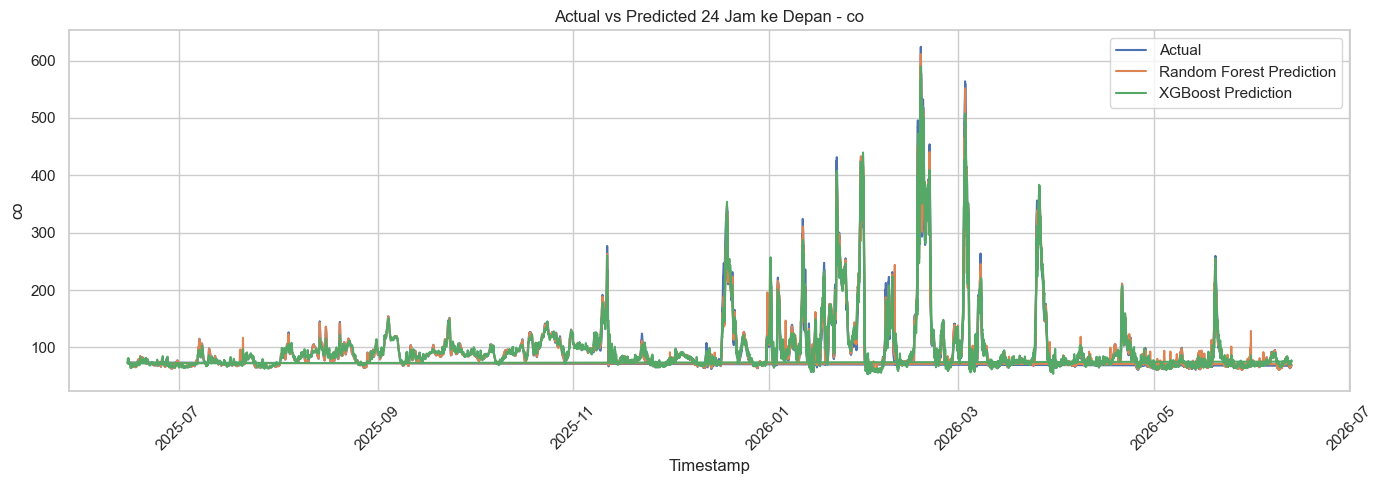

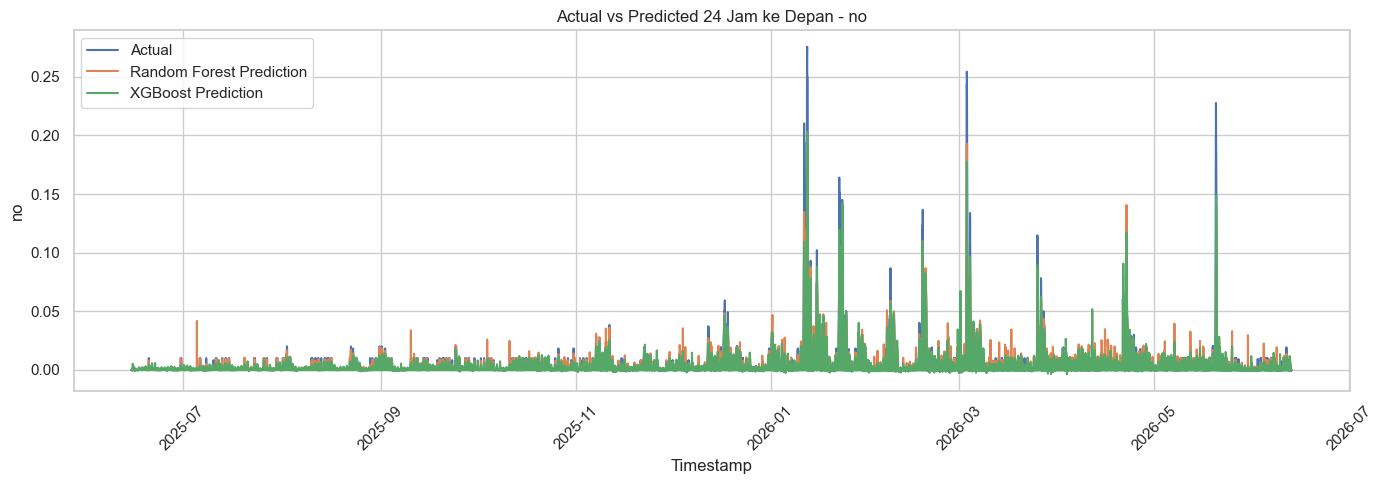

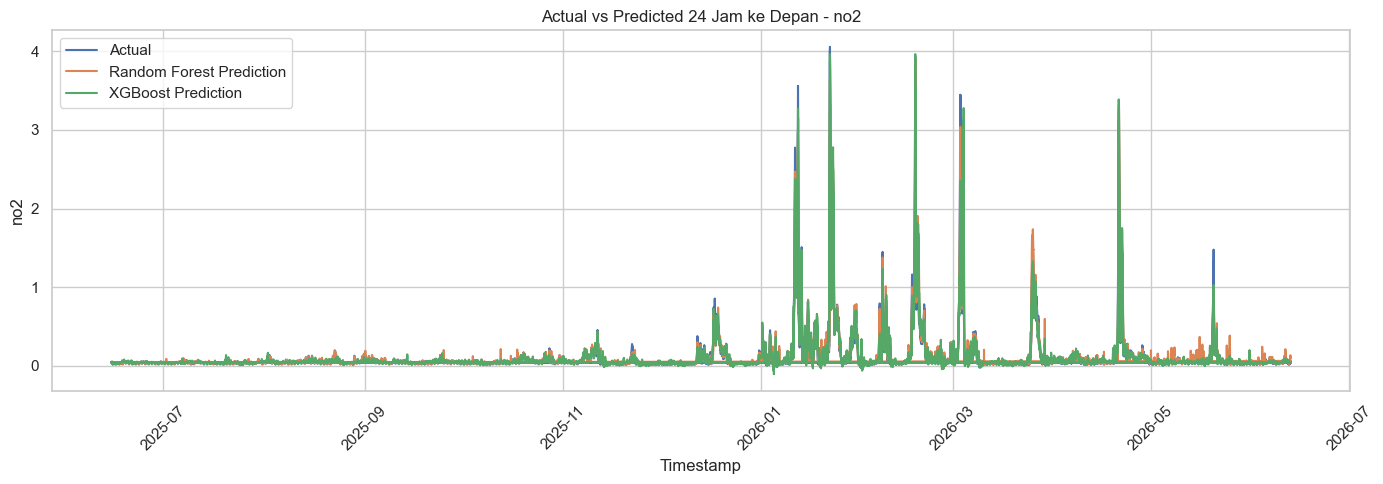

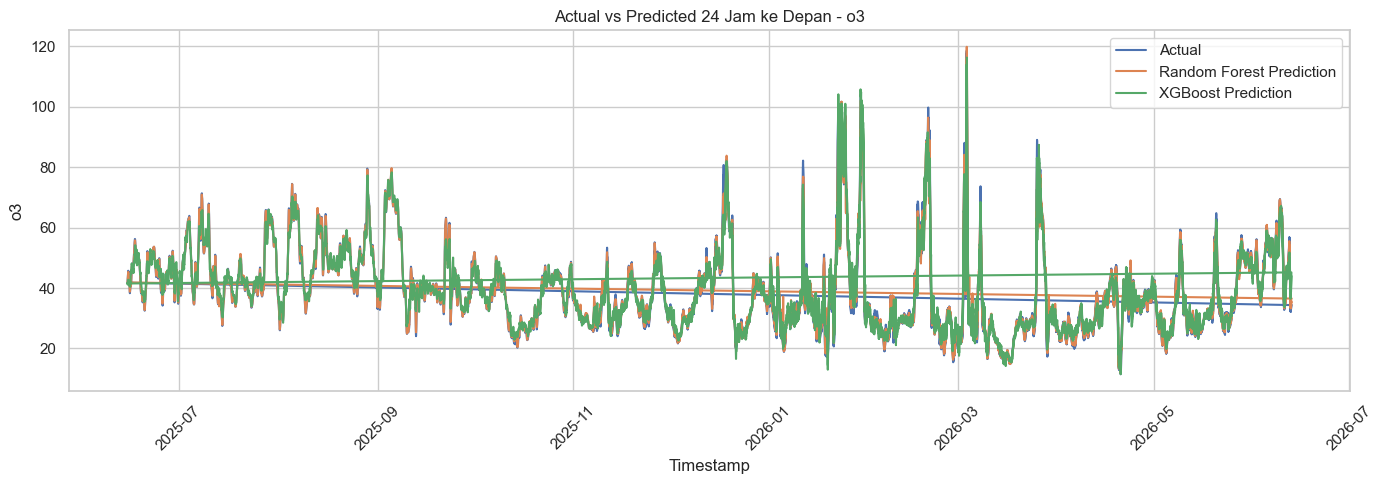

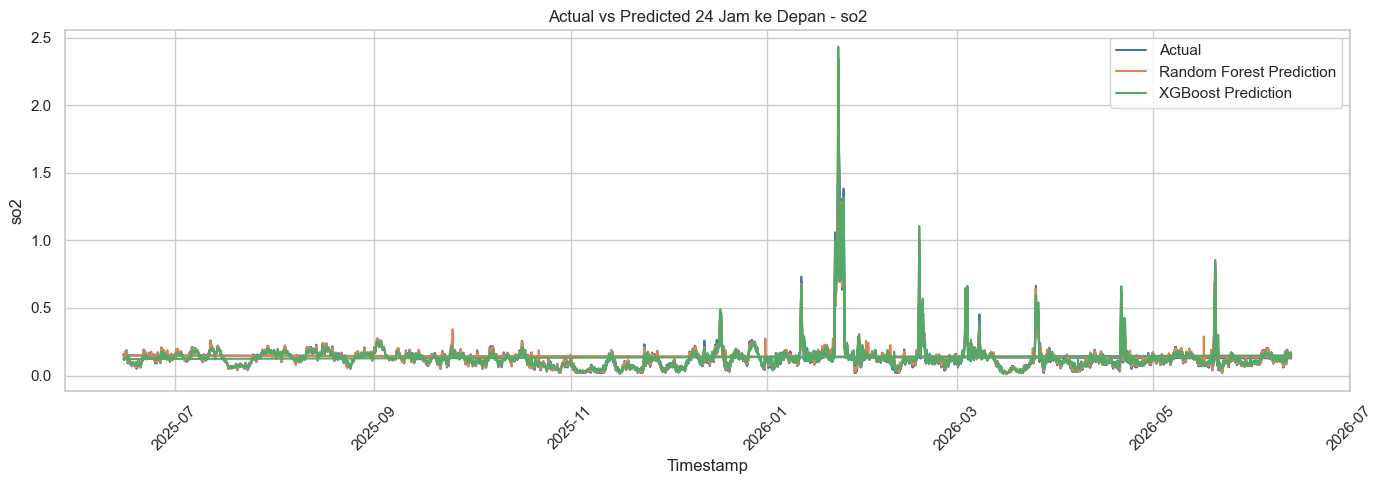

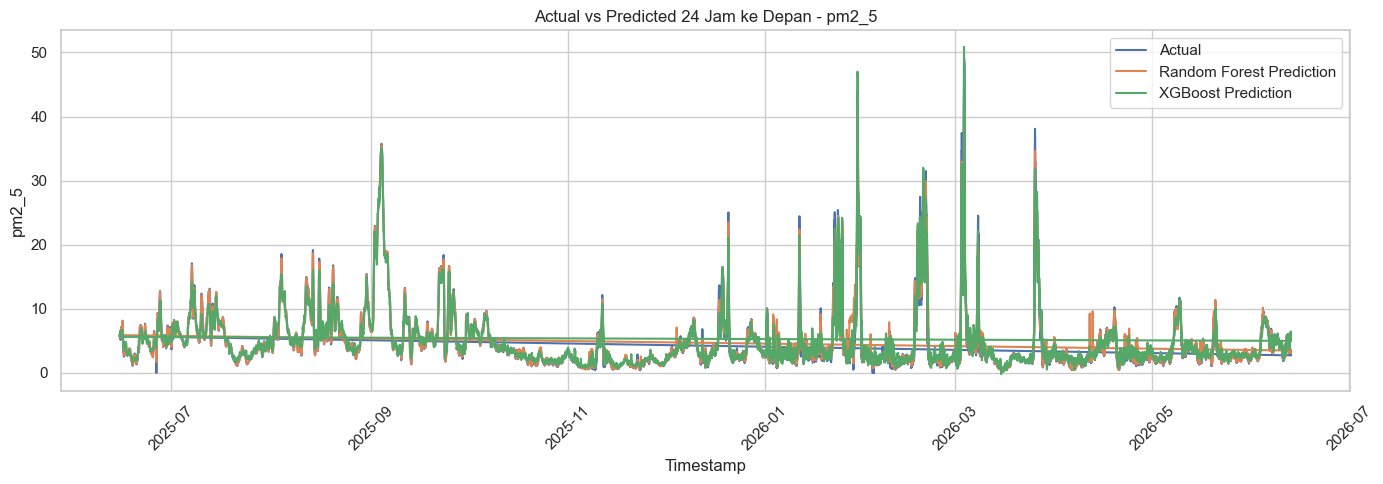

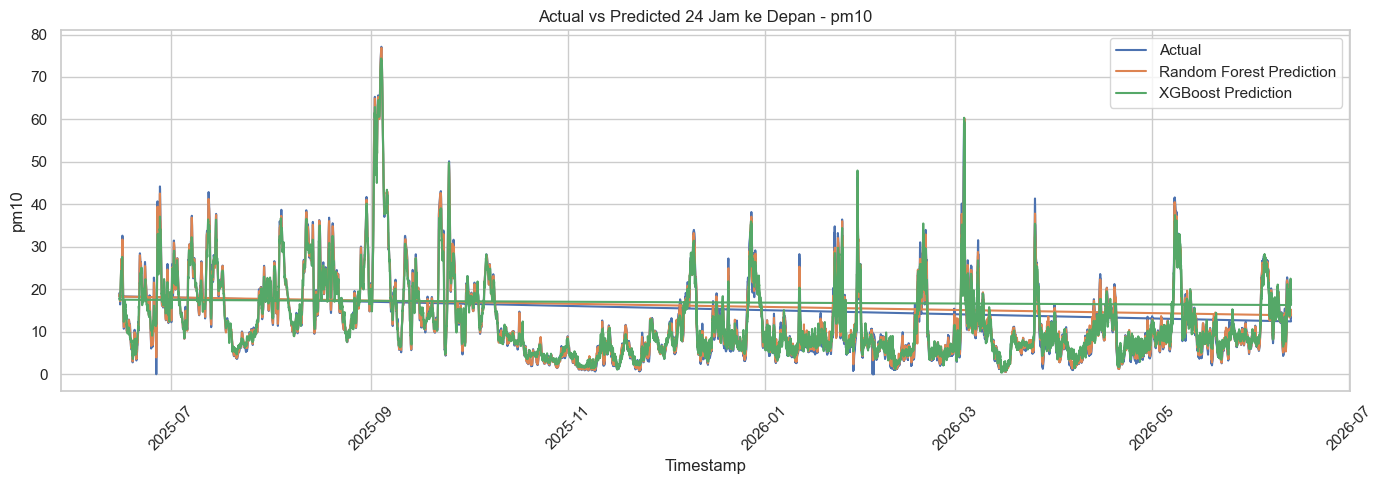

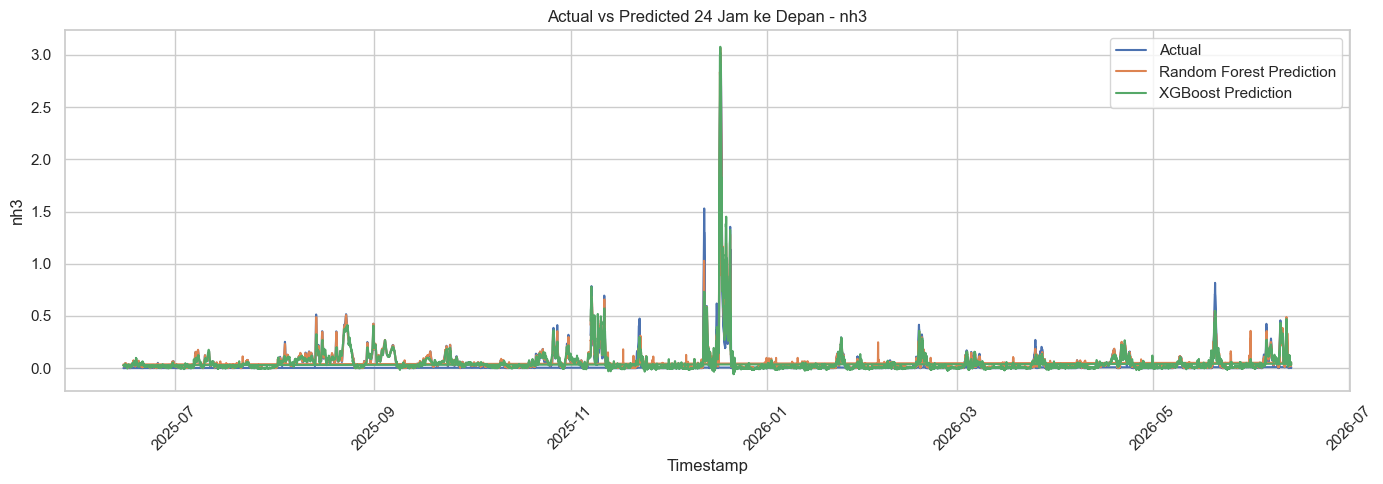

In [17]:
# =========================
# VISUALISASI ACTUAL VS PREDICTED
# =========================

for pollutant in pollutant_cols:
    plt.figure(figsize=(14, 5))

    plt.plot(
        predictions["timestamp_hour"],
        predictions[f"{pollutant}_actual"],
        label="Actual"
    )

    plt.plot(
        predictions["timestamp_hour"],
        predictions[f"{pollutant}_rf_pred"],
        label="Random Forest Prediction"
    )

    plt.plot(
        predictions["timestamp_hour"],
        predictions[f"{pollutant}_xgb_pred"],
        label="XGBoost Prediction"
    )

    plt.title(f"Actual vs Predicted 24 Jam ke Depan - {pollutant}")
    plt.xlabel("Timestamp")
    plt.ylabel(pollutant)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [18]:
# =========================
# SIMPAN MODEL TERBAIK PER POLUTAN
# UNTUK PREDIKSI 24 JAM KE DEPAN
# BERDASARKAN RMSE TERKECIL
# =========================


MODEL_DIR = "D:/saved_best_models"
os.makedirs(MODEL_DIR, exist_ok=True)

best_models = {}
best_model_summary = []

for _, row in best_model_per_pollutant.iterrows():
    pollutant = row["pollutant"]
    model_name = row["model"]

    # Ambil model terbaik sesuai hasil evaluasi
    if model_name == "Random Forest Regressor":
        best_model = rf_models[pollutant]
        model_code = "random_forest"

    elif model_name == "XGBoost Regressor":
        best_model = xgb_models[pollutant]
        model_code = "xgboost"

    else:
        raise ValueError(f"Model tidak dikenal: {model_name}")

    # Nama file model
    model_path = os.path.join(
        MODEL_DIR,
        f"{pollutant}_best_model.joblib"
    )

    # Simpan model
    joblib.dump(best_model, model_path)

    best_models[pollutant] = best_model

    best_model_summary.append({
        "pollutant": pollutant,
        "best_model": model_name,
        "model_code": model_code,
        "target": f"{pollutant}_target_24h",
        "prediction_meaning": "prediksi nilai polutan 24 jam setelah timestamp input",
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2": row["R2"],
        "model_path": model_path
    })

best_model_summary_df = pd.DataFrame(best_model_summary)

summary_path = os.path.join(MODEL_DIR, "best_model_summary.csv")
best_model_summary_df.to_csv(summary_path, index=False)


# =========================
# SIMPAN METADATA
# =========================

feature_names = list(X_train.columns)

metadata = {
    "feature_names": feature_names,
    "pollutant_cols": list(pollutant_cols),
    "target_horizon": "24h",
    "prediction_type": "rolling_24h_ahead_per_timestamp",
    "prediction_meaning": "setiap timestamp input menghasilkan prediksi untuk 24 jam setelah timestamp tersebut",
    "selection_metric": "RMSE terkecil",
    "model_level": "regency"
}

metadata_path = os.path.join(MODEL_DIR, "metadata.json")

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Model terbaik per polutan berhasil disimpan.")
print("Folder penyimpanan:", MODEL_DIR)
print("Summary:", summary_path)
print("Metadata:", metadata_path)

display(best_model_summary_df)

Model terbaik per polutan berhasil disimpan.
Folder penyimpanan: D:/saved_best_models
Summary: D:/saved_best_models\best_model_summary.csv
Metadata: D:/saved_best_models\metadata.json


,pollutant,best_model,model_code,target,prediction_meaning,MAE,RMSE,R2,model_path
0,co,Random Forest Regressor,random_forest,co_target_24h,prediksi nilai polutan 24 jam setelah timestam...,3.230530,9.265182,0.978166,D:/saved_best_models\co_best_model.joblib
1,nh3,XGBoost Regressor,xgboost,nh3_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.021602,0.049405,0.905252,D:/saved_best_models\nh3_best_model.joblib
2,no,XGBoost Regressor,xgboost,no_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.002214,0.005719,0.805051,D:/saved_best_models\no_best_model.joblib
3,no2,Random Forest Regressor,random_forest,no2_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.021022,0.062066,0.959024,D:/saved_best_models\no2_best_model.joblib
4,o3,Random Forest Regressor,random_forest,o3_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.781717,1.745969,0.984892,D:/saved_best_models\o3_best_model.joblib
5,pm10,Random Forest Regressor,random_forest,pm10_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.558215,0.955397,0.988816,D:/saved_best_models\pm10_best_model.joblib
6,pm2_5,Random Forest Regressor,random_forest,pm2_5_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.330867,0.857883,0.967864,D:/saved_best_models\pm2_5_best_model.joblib
7,so2,Random Forest Regressor,random_forest,so2_target_24h,prediksi nilai polutan 24 jam setelah timestam...,0.008916,0.021745,0.970619,D:/saved_best_models\so2_best_model.joblib
